In [1]:
import numpy as np
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('ggplot')

import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torch import nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch.cuda.amp import autocast, GradScaler
from torchmetrics.classification import MultilabelF1Score
import networkx as nx

MAIN_DIR = '/kaggle/input/cafa-6-protein-function-prediction'

class Config:
    train_sequences_path = MAIN_DIR + "/Train/train_sequences.fasta"
    train_labels_path = MAIN_DIR + "/Train/train_terms.tsv"
    test_sequences_path = MAIN_DIR + "/Test/testsuperset.fasta"
    ia_path = MAIN_DIR + "/IA.tsv"
    go_graph_path = MAIN_DIR + "/go-basic.obo"
    
    num_labels = 500
    n_epochs = 10
    batch_size = 64
    accumulation_steps = 2
    lr = 5e-4
    weight_decay = 0.01
    warmup_steps = 1000
    max_grad_norm = 1.0
    label_smoothing = 0.1
    focal_alpha = 0.25
    focal_gamma = 2.0
    
    # Model architecture
    d_model = 768
    num_heads = 12
    num_layers = 6
    dropout = 0.1
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    use_amp = True


class ProteinDataset(Dataset):
    def __init__(self, emb_path, id_path, labels_path=None, ia_weights=None, datatype="train"):
        super().__init__()
        self.datatype = datatype
        
        # Load embeddings
        embeds = np.load(emb_path)
        ids = np.load(id_path)
        
        # Data augmentation: add noise to embeddings
        if datatype == "train":
            noise = np.random.normal(0, 0.01, embeds.shape)
            embeds = embeds + noise
        
        self.df = pd.DataFrame({
            "EntryID": ids,
            "embed": [embeds[i] for i in range(embeds.shape[0])]
        })
        
        if datatype == "train":
            np_labels = np.load(labels_path)
            df_labels = pd.DataFrame(self.df['EntryID'])
            df_labels['labels_vect'] = [row for row in np_labels]
            self.df = self.df.merge(df_labels, on="EntryID")
            
            # Load IA weights if provided
            if ia_weights is not None:
                self.ia_weights = torch.tensor(ia_weights, dtype=torch.float32)
            else:
                self.ia_weights = torch.ones(Config.num_labels)
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, index):
        embed = torch.tensor(self.df.iloc[index]["embed"], dtype=torch.float32)
        
        if self.datatype == "train":
            targets = torch.tensor(self.df.iloc[index]["labels_vect"], dtype=torch.float32)
            return embed, targets, self.ia_weights
        else:
            id = self.df.iloc[index]["EntryID"]
            return embed, id


class FocalLoss(nn.Module):
    """Focal Loss for handling class imbalance"""
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    
    def forward(self, inputs, targets, weights=None):
        bce = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce)
        focal = self.alpha * (1 - pt) ** self.gamma * bce
        
        if weights is not None:
            focal = focal * weights.unsqueeze(0)
        
        return focal.mean()


class HierarchicalLoss(nn.Module):
    """Loss that considers GO hierarchy"""
    def __init__(self, go_graph=None):
        super().__init__()
        self.focal = FocalLoss(alpha=Config.focal_alpha, gamma=Config.focal_gamma)
        self.go_graph = go_graph
    
    def forward(self, preds, targets, weights=None):
        # Base focal loss
        loss = self.focal(preds, targets, weights)
        
        # Hierarchical consistency penalty
        if self.go_graph is not None:
            # Ensure child terms have lower or equal confidence than parents
            hierarchy_penalty = self._compute_hierarchy_penalty(preds)
            loss = loss + 0.1 * hierarchy_penalty
        
        return loss
    
    def _compute_hierarchy_penalty(self, preds):
        # Simplified - would need actual parent-child relationships
        return torch.tensor(0.0, device=preds.device)


class MultiHeadAttentionWithRelPos(nn.Module):
    """Multi-head attention with relative position encoding"""
    def __init__(self, d_model, num_heads, dropout=0.1, max_rel_dist=32):
        super().__init__()
        assert d_model % num_heads == 0
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.scale = self.head_dim ** -0.5
        
        self.qkv = nn.Linear(d_model, d_model * 3)
        self.dropout = nn.Dropout(dropout)
        self.out_proj = nn.Linear(d_model, d_model)
        
        # Relative position embeddings
        self.max_rel_dist = max_rel_dist
        self.rel_pos_emb = nn.Embedding(2 * max_rel_dist + 1, self.head_dim)
    
    def forward(self, x, mask=None):
        B, N, C = x.shape
        
        # Linear projection and reshape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        
        # Attention scores
        attn = (q @ k.transpose(-2, -1)) * self.scale
        
        # Add relative position bias
        rel_pos_bias = self._get_rel_pos_bias(N)
        attn = attn + rel_pos_bias.unsqueeze(0).unsqueeze(0)
        
        if mask is not None:
            attn = attn.masked_fill(mask == 0, float('-inf'))
        
        attn = F.softmax(attn, dim=-1)
        attn = self.dropout(attn)
        
        # Weighted sum
        out = (attn @ v).transpose(1, 2).reshape(B, N, C)
        out = self.out_proj(out)
        
        return out, attn
    
    def _get_rel_pos_bias(self, seq_len):
        positions = torch.arange(seq_len, device=next(self.parameters()).device)
        rel_pos = positions.unsqueeze(0) - positions.unsqueeze(1)
        rel_pos = torch.clamp(rel_pos, -self.max_rel_dist, self.max_rel_dist) + self.max_rel_dist
        return self.rel_pos_emb(rel_pos).sum(dim=-1)


class TransformerBlock(nn.Module):
    """Enhanced transformer block with residual connections"""
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        self.attention = MultiHeadAttentionWithRelPos(d_model, num_heads, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        
        # FFN with GELU
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model),
            nn.Dropout(dropout)
        )
        
        # LayerScale for training stability
        self.gamma1 = nn.Parameter(torch.ones(d_model) * 0.1)
        self.gamma2 = nn.Parameter(torch.ones(d_model) * 0.1)
    
    def forward(self, x, mask=None):
        # Self-attention with residual
        attn_out, attn_weights = self.attention(self.norm1(x), mask)
        x = x + self.gamma1 * attn_out
        
        # FFN with residual
        ffn_out = self.ffn(self.norm2(x))
        x = x + self.gamma2 * ffn_out
        
        return x, attn_weights


class ImprovedProteinFunctionPredictor(nn.Module):
    """Enhanced model with transformer architecture"""
    def __init__(self, input_dim=2560, num_classes=500):
        super().__init__()
        
        # Input projection
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, Config.d_model),
            nn.LayerNorm(Config.d_model),
            nn.Dropout(Config.dropout)
        )
        
        # Positional encoding
        self.pos_encoding = nn.Parameter(torch.randn(1, 1, Config.d_model) * 0.02)
        
        # Transformer blocks
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(Config.d_model, Config.num_heads, Config.dropout)
            for _ in range(Config.num_layers)
        ])
        
        # Global pooling
        self.pool = nn.AdaptiveAvgPool1d(1)
        
        # Multi-scale feature extraction
        self.multi_scale = nn.ModuleList([
            nn.Conv1d(Config.d_model, Config.d_model // 4, kernel_size=k, padding=k//2)
            for k in [3, 5, 7, 9]
        ])
        
        # Classification head with multiple layers
        self.classifier = nn.Sequential(
            nn.Linear(Config.d_model * 2, Config.d_model),
            nn.LayerNorm(Config.d_model),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(Config.d_model, Config.d_model // 2),
            nn.LayerNorm(Config.d_model // 2),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(Config.d_model // 2, num_classes)
        )
        
        # Temperature parameter for calibration
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)
    
    def forward(self, x, return_attention=False):
        batch_size = x.shape[0]
        
        # Project input
        x = self.input_proj(x)
        x = x.unsqueeze(1)  # Add sequence dimension
        x = x + self.pos_encoding
        
        # Store attention weights
        attention_weights = []
        
        # Apply transformer blocks
        for block in self.transformer_blocks:
            x, attn = block(x)
            if return_attention:
                attention_weights.append(attn)
        
        # Multi-scale features
        x_permuted = x.permute(0, 2, 1)  # (B, D, N)
        multi_scale_feats = [conv(x_permuted) for conv in self.multi_scale]
        multi_scale_feats = torch.cat(multi_scale_feats, dim=1)
        multi_scale_pooled = self.pool(multi_scale_feats).squeeze(-1)
        
        # Global pooling
        x_pooled = x.mean(dim=1)
        
        # Concatenate features
        combined = torch.cat([x_pooled, multi_scale_pooled], dim=1)
        
        # Classification
        logits = self.classifier(combined)
        
        if return_attention:
            return logits, attention_weights
        return logits
    
    def predict_calibrated(self, x):
        """Predictions with temperature scaling"""
        logits = self.forward(x)
        return torch.sigmoid(logits / self.temperature)


def load_ia_weights(ia_path, num_labels=500):
    """Load information accretion weights"""
    try:
        ia_df = pd.read_csv(ia_path, sep='\t', names=['term', 'weight'])
        # Map to top 500 terms - would need actual mapping
        weights = np.ones(num_labels)
        return weights
    except:
        return np.ones(num_labels)


def train_model_advanced(model, train_dataset, val_dataset, ia_weights=None):
    """Enhanced training with mixed precision and advanced techniques"""
    
    train_loader = DataLoader(train_dataset, batch_size=Config.batch_size, 
                              shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=Config.batch_size, 
                           shuffle=False, num_workers=2, pin_memory=True)
    
    # Optimizer with weight decay
    optimizer = torch.optim.AdamW(model.parameters(), lr=Config.lr, 
                                  weight_decay=Config.weight_decay)
    
    # Scheduler with warmup
    scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)
    
    # Loss function
    criterion = HierarchicalLoss()
    
    # Mixed precision
    scaler = GradScaler() if Config.use_amp else None
    
    # Metrics
    f1_metric = MultilabelF1Score(num_labels=Config.num_labels).to(Config.device)
    
    train_loss_history = []
    val_loss_history = []
    train_f1_history = []
    val_f1_history = []
    best_val_f1 = 0.0
    
    print("BEGIN ADVANCED TRAINING...")
    
    for epoch in range(Config.n_epochs):
        print(f"\nEPOCH {epoch + 1}/{Config.n_epochs}")
        
        # Training phase
        model.train()
        train_losses = []
        train_scores = []
        optimizer.zero_grad()
        
        for batch_idx, (embed, targets, weights) in enumerate(tqdm(train_loader)):
            embed = embed.to(Config.device)
            targets = targets.to(Config.device)
            weights = weights.to(Config.device)
            
            # Label smoothing
            targets_smooth = targets * (1 - Config.label_smoothing) + Config.label_smoothing / 2
            
            # Mixed precision forward pass
            if Config.use_amp:
                with autocast():
                    preds = model(embed)
                    loss = criterion(preds, targets_smooth, weights) / Config.accumulation_steps
                
                scaler.scale(loss).backward()
                
                if (batch_idx + 1) % Config.accumulation_steps == 0:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), Config.max_grad_norm)
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad()
            else:
                preds = model(embed)
                loss = criterion(preds, targets_smooth, weights) / Config.accumulation_steps
                loss.backward()
                
                if (batch_idx + 1) % Config.accumulation_steps == 0:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), Config.max_grad_norm)
                    optimizer.step()
                    optimizer.zero_grad()
            
            train_losses.append(loss.item() * Config.accumulation_steps)
            
            with torch.no_grad():
                score = f1_metric(preds, targets.int())
                train_scores.append(score.item())
        
        avg_train_loss = np.mean(train_losses)
        avg_train_f1 = np.mean(train_scores)
        train_loss_history.append(avg_train_loss)
        train_f1_history.append(avg_train_f1)
        
        print(f"Train Loss: {avg_train_loss:.4f} | Train F1: {avg_train_f1:.4f}")
        
        # Validation phase
        model.eval()
        val_losses = []
        val_scores = []
        
        with torch.no_grad():
            for embed, targets, weights in val_loader:
                embed = embed.to(Config.device)
                targets = targets.to(Config.device)
                weights = weights.to(Config.device)
                
                if Config.use_amp:
                    with autocast():
                        preds = model(embed)
                        loss = criterion(preds, targets, weights)
                else:
                    preds = model(embed)
                    loss = criterion(preds, targets, weights)
                
                val_losses.append(loss.item())
                score = f1_metric(preds, targets.int())
                val_scores.append(score.item())
        
        avg_val_loss = np.mean(val_losses)
        avg_val_f1 = np.mean(val_scores)
        val_loss_history.append(avg_val_loss)
        val_f1_history.append(avg_val_f1)
        
        print(f"Val Loss: {avg_val_loss:.4f} | Val F1: {avg_val_f1:.4f}")
        
        # Save best model
        if avg_val_f1 > best_val_f1:
            best_val_f1 = avg_val_f1
            torch.save(model.state_dict(), 'best_model.pth')
            print(f"✓ New best model saved! F1: {best_val_f1:.4f}")
        
        scheduler.step()
    
    print(f"\nTraining Complete! Best Val F1: {best_val_f1:.4f}")
    
    return model, {
        'train_loss': train_loss_history,
        'val_loss': val_loss_history,
        'train_f1': train_f1_history,
        'val_f1': val_f1_history
    }


def predict_with_tta(model, test_dataset, num_tta=3):
    """Prediction with test-time augmentation"""
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)
    model.eval()
    
    labels = pd.read_csv(Config.train_labels_path, sep="\t")
    top_terms = labels.groupby("term")["EntryID"].count().sort_values(ascending=False)
    labels_names = top_terms[:Config.num_labels].index.values
    
    all_predictions = []
    
    print("Generating predictions with TTA...")
    
    for tta_iter in range(num_tta):
        predictions = []
        
        with torch.no_grad():
            for embed, id in tqdm(test_loader):
                embed = embed.to(Config.device)
                
                # Add slight noise for TTA
                if tta_iter > 0:
                    noise = torch.randn_like(embed) * 0.01
                    embed = embed + noise
                
                # Calibrated predictions
                probs = model.predict_calibrated(embed)
                predictions.append(probs.cpu().numpy())
        
        all_predictions.append(np.vstack(predictions))
    
    # Average TTA predictions
    final_predictions = np.mean(all_predictions, axis=0)
    
    # Create submission
    ids = np.repeat([test_dataset.df.iloc[i]['EntryID'] for i in range(len(test_dataset))], 
                    Config.num_labels)
    go_terms = np.tile(labels_names, len(test_dataset))
    confs = final_predictions.flatten()
    
    submission_df = pd.DataFrame({
        "Id": ids,
        "GO term": go_terms,
        "Confidence": confs
    })
    
    # Filter low confidence predictions
    submission_df = submission_df[submission_df['Confidence'] > 0.01]
    
    return submission_df

In [2]:
# Initialize datasets
ia_weights = load_ia_weights(Config.ia_path, Config.num_labels)

top = "/kaggle/input/train-targets-top500/train_targets_top500.npy"
dataset = "/kaggle/input/protbert-embeddings-for-cafa5"

train_emb = f"{dataset}/train_embeddings.npy"
train_id = f"{dataset}/train_ids.npy"
test_emb = f"{dataset}/test_embeddings.npy"
test_id = f"{dataset}/test_ids.npy"

train_dataset = ProteinDataset(train_emb, train_id, top, ia_weights, datatype="train")
test_dataset = ProteinDataset(test_emb, test_id, datatype="test")

# Split dataset
train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_set, val_set = random_split(train_dataset, [train_size, val_size])

# Initialize model
model = ImprovedProteinFunctionPredictor(input_dim=1024, num_classes=Config.num_labels)
model = model.to(Config.device)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# Train
model, history = train_model_advanced(model, train_set, val_set, ia_weights)

/tmp/ipykernel_19/2449603216.py:337: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if Config.use_amp else None


Model parameters: 48,561,141
BEGIN ADVANCED TRAINING...

EPOCH 1/10


  0%|          | 0/2001 [00:00<?, ?it/s]/tmp/ipykernel_19/2449603216.py:369: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
100%|██████████| 2001/2001 [01:15<00:00, 26.34it/s]

Train Loss: 0.0135 | Train F1: 0.0092



/tmp/ipykernel_19/2449603216.py:416: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


...

Train Loss: 0.0123 | Train F1: 0.0149


Val Loss: 0.0108 | Val F1: 0.0140

EPOCH 10/10


100%|██████████| 2001/2001 [01:13<00:00, 27.04it/s]

Train Loss: 0.0122 | Train F1: 0.0152


Val Loss: 0.0108 | Val F1: 0.0146

Training Complete! Best Val F1: 0.0150


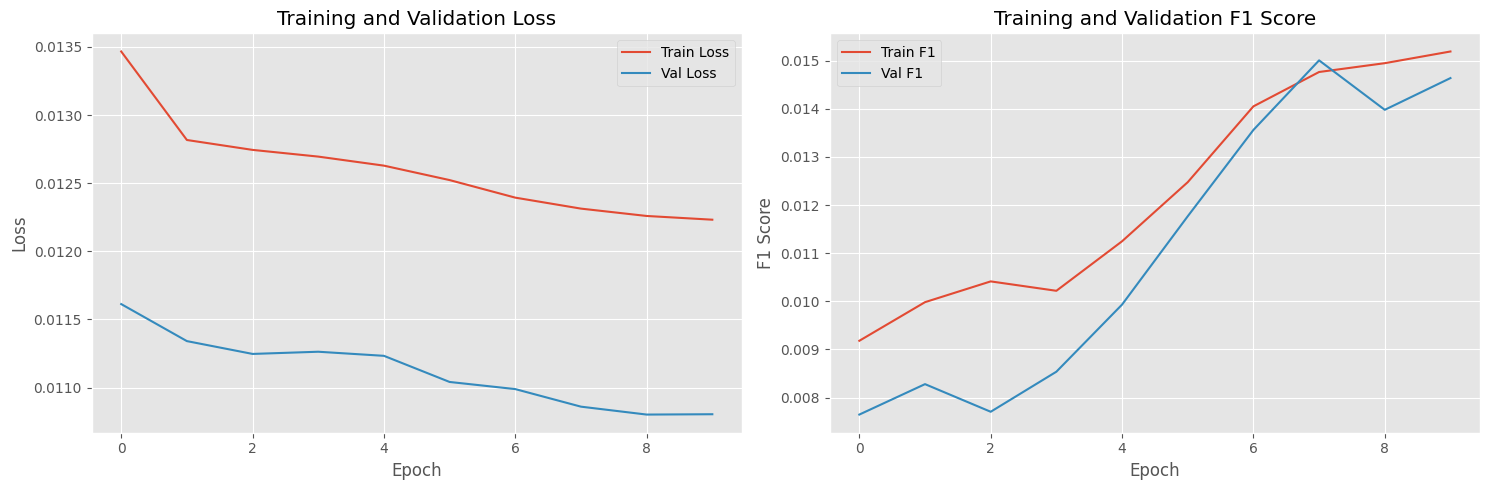

✓ Loaded best model checkpoint
Generating predictions with TTA...


100%|██████████| 141865/141865 [13:49<00:00, 171.07it/s]



✓ Submission saved! Total predictions: 70932500


In [3]:
# Plot results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['val_loss'], label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()

ax2.plot(history['train_f1'], label='Train F1')
ax2.plot(history['val_f1'], label='Val F1')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('F1 Score')
ax2.set_title('Training and Validation F1 Score')
ax2.legend()

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()

# Load best model and predict
try:
    model.load_state_dict(torch.load('best_model.pth'))
    print("✓ Loaded best model checkpoint")
except FileNotFoundError:
    print("⚠ No checkpoint found, using current model state")

submission_df = predict_with_tta(model, test_dataset, num_tta=3)

# Save submission
submission_df.to_csv('submission.tsv', sep='\t', header=False, index=False)
print(f"\n✓ Submission saved! Total predictions: {len(submission_df)}")